# MSE 546 - SVM Model: Detecting AI-Generated Text

**Team 13**

This notebook implements an SVM model for the Kaggle competition "LLM - Detect AI Generated Text"

**Approach:** TF-IDF Vectorization + Support Vector Machine (LinearSVC)

---

## Step 0: Setup for Google Colab

**If running in Google Colab**, run the cell below to upload your data file.

**If running locally** (Jupyter on your computer), skip this cell.

In [1]:
# ============================================================
# GOOGLE COLAB SETUP - Run this cell if using Colab
# ============================================================

import os

# Check if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally (not in Colab)")

if IN_COLAB:
    from google.colab import files

    # Check if data file already exists
    if not os.path.exists('train_v4_drcat_01.csv'):
        print("\n" + "="*50)
        print("Please upload 'train_v4_drcat_01.csv'")
        print("(from your DAIGT-V4-TRAIN-DATASEt folder)")
        print("="*50 + "\n")
        uploaded = files.upload()
        print("\nFile uploaded successfully!")
    else:
        print("Data file already exists, skipping upload.")

Running in Google Colab

Please upload 'train_v4_drcat_01.csv'
(from your DAIGT-V4-TRAIN-DATASEt folder)



Saving train_v4_drcat_01.csv to train_v4_drcat_01.csv

File uploaded successfully!


---

## Step 1: Import Libraries and Load Data

We start by importing the necessary libraries:
- `pandas`: For data manipulation
- `sklearn`: For machine learning (TF-IDF, LinearSVC, calibration, metrics)
- `matplotlib/seaborn`: For visualization

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Set random seed for reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


### Load the External Dataset

We use the DAIGT-V4 dataset which contains:
- ~27,000 human-written essays (from PERSUADE corpus)
- ~46,000 AI-generated essays (from 20+ different LLMs)

This balanced dataset allows us to train a meaningful classifier.

In [3]:
# ============================================================
# Load Data - Automatically detects Colab vs Local
# ============================================================

import os

# Try different paths (Colab vs Local)
possible_paths = [
    "train_v4_drcat_01.csv",                              # Colab (uploaded file)
    "DAIGT-V4-TRAIN-DATASEt/train_v4_drcat_01.csv",       # Local (subfolder)
    "../DAIGT-V4-TRAIN-DATASEt/train_v4_drcat_01.csv",    # Local (parent folder)
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find data file! Please either:\n"
        "1. Upload 'train_v4_drcat_01.csv' in Colab, or\n"
        "2. Make sure the DAIGT-V4 folder is in the correct location locally"
    )

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

# Display basic info
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading data from: train_v4_drcat_01.csv

Dataset shape: (73573, 6)
Columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'model']

First few rows:


,text,label,prompt_name,source,RDizzl3_seven,model
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False,human
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False,human
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False,human
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False,human
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False,human


In [4]:
# Check class distribution
print("Class Distribution:")
print(df['label'].value_counts())
print(f"\nPercentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(2))

Class Distribution:
label
1    46203
0    27370
Name: count, dtype: int64

Percentages:
label
1    62.8
0    37.2
Name: proportion, dtype: float64


### Prepare the Data

We only need two columns:
- `text`: The essay content (our input/features)
- `label`: 0 = human-written, 1 = AI-generated (our target)

In [5]:
# Keep only the columns we need
X = df['text']   # Features (the essay text)
y = df['label']  # Target (0 = human, 1 = AI)

print(f"Number of essays: {len(X)}")
print(f"Number of labels: {len(y)}")

# Check for any missing values
print(f"\nMissing values in text: {X.isna().sum()}")
print(f"Missing values in label: {y.isna().sum()}")

Number of essays: 73573
Number of labels: 73573

Missing values in text: 0
Missing values in label: 0


---

## Step 2: Train-Test Split

We split our data into:
- **Training set (80%)**: Used to train the model
- **Test set (20%)**: Used to evaluate the model (never seen during training)

We use **stratified sampling** to ensure both sets have the same proportion of human vs AI essays.

> This is identical to the baseline split to ensure fair comparison.

In [6]:
# Split data: 80% train, 20% test
# stratify=y ensures both sets have same class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,              # 20% for testing
    random_state=RANDOM_STATE,  # For reproducibility
    stratify=y                  # Maintain class proportions
)

print(f"Training set size: {len(X_train)} essays")
print(f"Test set size: {len(X_test)} essays")

# Verify stratification worked
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set size: 58858 essays
Test set size: 14715 essays

Training set class distribution:
label
1    62.8
0    37.2
Name: proportion, dtype: float64

Test set class distribution:
label
1    62.8
0    37.2
Name: proportion, dtype: float64


---

## Step 3: TF-IDF Vectorization

We use the same TF-IDF parameters as the baseline for a fair comparison.

**Parameters:**
- `max_features=10000`: Keep only the 10,000 most important words
- `ngram_range=(1,2)`: Include single words AND two-word phrases (bigrams)
- `min_df=3`: Ignore words that appear in fewer than 3 documents
- `max_df=0.9`: Ignore words that appear in >90% of documents

In [7]:
# Create TF-IDF vectorizer - identical parameters to baseline
tfidf = TfidfVectorizer(
    max_features=10000,    # Limit vocabulary size
    ngram_range=(1, 2),    # Use unigrams and bigrams
    min_df=3,              # Ignore rare words
    max_df=0.9,            # Ignore very common words
    stop_words='english'   # Remove common English words (the, is, at, etc.)
)

# Fit on training data and transform
# IMPORTANT: We fit ONLY on training data to avoid data leakage
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data (using vocabulary learned from training)
print("Transforming test data...")
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTraining data shape: {X_train_tfidf.shape}")
print(f"Test data shape: {X_test_tfidf.shape}")
print(f"\nEach essay is now represented as a vector of {X_train_tfidf.shape[1]} features")

Fitting TF-IDF on training data...
Transforming test data...

Training data shape: (58858, 10000)
Test data shape: (14715, 10000)

Each essay is now represented as a vector of 10000 features


---

## Step 4: Train SVM Model

**Support Vector Machine (SVM)** finds the hyperplane that maximally separates the two classes in high-dimensional TF-IDF feature space.

We use **LinearSVC** which is optimized for large, sparse text datasets and is significantly faster than a kernelized SVM.

Since `LinearSVC` does not natively output probabilities (needed for ROC-AUC), we wrap it with `CalibratedClassifierCV` which uses cross-validation to fit a calibration layer on top.

In [8]:
# LinearSVC wrapped with CalibratedClassifierCV to enable probability output
svm = CalibratedClassifierCV(
    LinearSVC(
        C=1.0,           # Regularization strength (default)
        max_iter=2000,   # Maximum iterations for convergence
        random_state=RANDOM_STATE
    )
)

print("Training SVM model...")
svm.fit(X_train_tfidf, y_train)
print("Training complete!")

Training SVM model...
Training complete!


---

## Step 5: Evaluate Model Performance

We evaluate on the **test set** (data the model has never seen) using:
- **ROC-AUC**: How well does the model rank AI essays above human essays?
- **Precision**: Of essays predicted as AI, what % actually were AI?
- **Recall**: Of all actual AI essays, what % did we catch?
- **F1-Score**: Harmonic mean of precision and recall

In [9]:
# Make predictions on test set
y_pred = svm.predict(X_test_tfidf)                    # Binary predictions (0 or 1)
y_pred_proba = svm.predict_proba(X_test_tfidf)[:, 1]  # Probability of class 1 (AI)

# Calculate metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("=" * 50)
print("SVM MODEL PERFORMANCE")
print("=" * 50)
print(f"\nROC-AUC Score:  {roc_auc:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-Score:       {f1:.4f}")
print("=" * 50)

SVM MODEL PERFORMANCE

ROC-AUC Score:  0.9949
Precision:      0.9811
Recall:         0.9686
F1-Score:       0.9748


In [10]:
# Detailed classification report
print("\nDetailed Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))


Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

   Human (0)       0.95      0.97      0.96      5474
      AI (1)       0.98      0.97      0.97      9241

    accuracy                           0.97     14715
   macro avg       0.96      0.97      0.97     14715
weighted avg       0.97      0.97      0.97     14715



### Confusion Matrix

The confusion matrix shows:
- **True Negatives (TN)**: Human essays correctly identified as human
- **False Positives (FP)**: Human essays incorrectly flagged as AI
- **False Negatives (FN)**: AI essays missed (incorrectly labeled as human)
- **True Positives (TP)**: AI essays correctly identified as AI

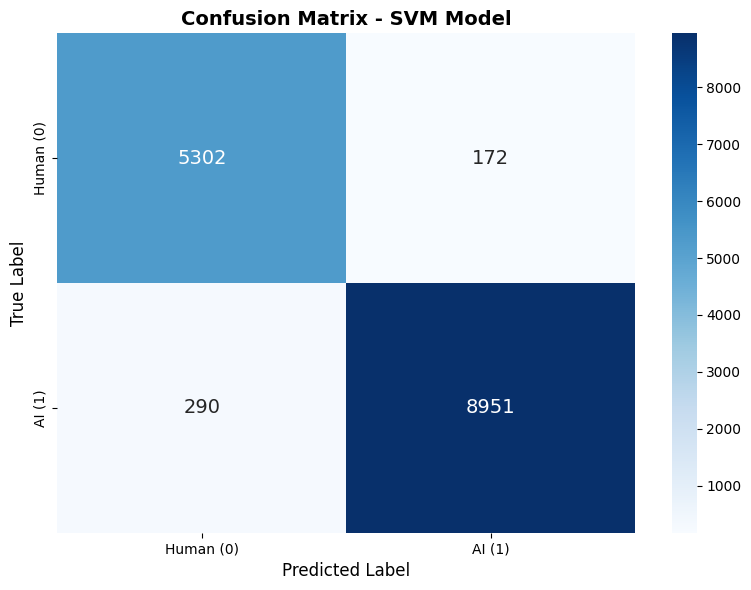


True Negatives (Human->Human):  5302
False Positives (Human->AI):    172
False Negatives (AI->Human):    290
True Positives (AI->AI):        8951


In [11]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'],
            annot_kws={'size': 14})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - SVM Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print raw numbers
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Human->Human):  {tn}")
print(f"False Positives (Human->AI):    {fp}")
print(f"False Negatives (AI->Human):    {fn}")
print(f"True Positives (AI->AI):        {tp}")

### ROC Curve

The ROC curve shows the tradeoff between True Positive Rate (catching AI essays) and False Positive Rate (falsely flagging human essays) at different classification thresholds.

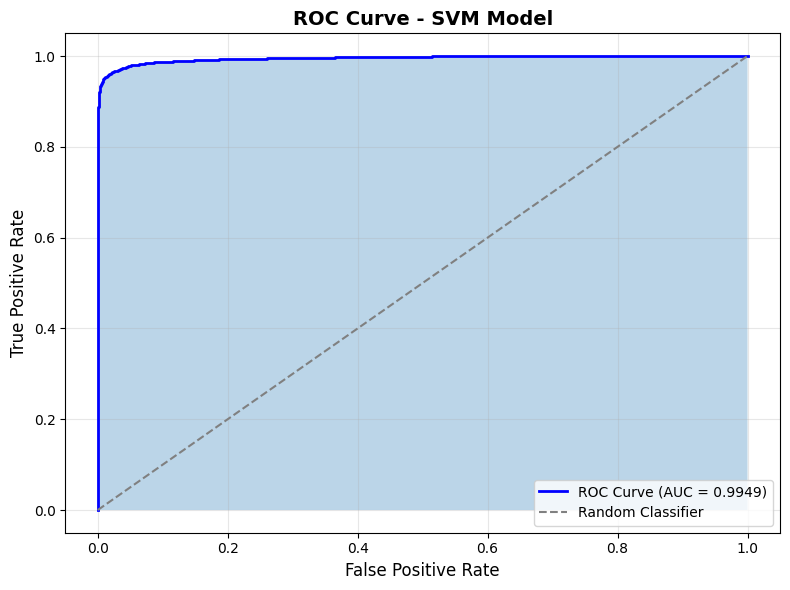

In [12]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.3)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - SVM Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 6: Comparison with Baseline

In [14]:
# Baseline results for reference
baseline = {
    'ROC-AUC': 0.9924,
    'Precision': 0.9803,
    'Recall': 0.9595,
    'F1-Score': 0.9698
}

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<15} {'Baseline (LR)':>15} {'SVM':>15} {'Delta':>10}")
print("-" * 60)
for metric, baseline_val in baseline.items():
    svm_val = {'ROC-AUC': roc_auc, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}[metric]
    delta = svm_val - baseline_val
    print(f"{metric:<15} {baseline_val:>15.4f} {svm_val:>15.4f} {delta:>+10.4f}")
print("=" * 60)

MODEL COMPARISON
Metric            Baseline (LR)             SVM      Delta
------------------------------------------------------------
ROC-AUC                  0.9924          0.9949    +0.0025
Precision                0.9803          0.9811    +0.0008
Recall                   0.9595          0.9686    +0.0091
F1-Score                 0.9698          0.9748    +0.0050
